In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scanpy as sc
sc.settings.verbosity = 3
sc.logging.print_header()
from matplotlib import rcParams

scanpy==1.9.8 anndata==0.10.9 umap==0.5.5 numpy==1.26.4 scipy==1.13.1 pandas==2.1.1 scikit-learn==1.5.1 statsmodels==0.14.1 igraph==0.11.6 pynndescent==0.5.11


In [2]:
frag_mbrain = list(pd.read_csv('yx_mbrain/yx_mbrain_signac_meta.csv', index_col=0)['fragments'])

In [3]:
frag_ME11 = list(pd.read_csv('yx_ME11/yx_ME11_signac_meta.csv', index_col=0)['fragments'])

In [4]:
frag_htonsil = list(pd.read_csv('yx_htonsil/yx_htonsil_signac_meta.csv', index_col=0)['fragments'])

In [5]:
frag_sATAC_E12 = list(pd.read_csv('sATAC_E12/sATAC_E12_signac_meta.csv', index_col=0)['fragments'])
frag_sATAC_E12 = [x for x in frag_sATAC_E12 if x >= 100]

In [6]:
frag_cuttag_E11 = list(pd.read_csv('yx_cuttag_E11/yx_CUTTag_ME11_signac_meta.csv', index_col=0)['fragments'])
frag_cuttag_E11 = [x for x in frag_cuttag_E11 if x >= 100]

In [7]:
ffpe_mbrain = list(pd.read_csv('../signac_output/mouse_brain_atac_20240828_meta.csv', index_col=0)['fragments'])

In [8]:
ffpe_mcolon = list(pd.read_csv('../signac_output/mouse_colon_20240910_meta.csv', index_col=0)['fragments'])

In [9]:
ffpe_malt = list(pd.read_csv('../MALT100/signac_output/20241014_MALT_8444x102293_meta.csv', index_col=0)['fragments'])

In [10]:
ffpe_LM19 = list(pd.read_csv('../signac_output/LYM_K27/20241108_LYM_K27_2400x21461_meta.csv', index_col=0)['fragments'])

In [11]:
frag_mbrain = [x /95570368*100000000 for x in frag_mbrain]
frag_ME11 = [x /128502176*100000000 for x in frag_ME11]
frag_htonsil = [x /71045324*100000000 for x in frag_htonsil]
frag_sATAC_E12 = [x /82679886*100000000*2 for x in frag_sATAC_E12]
frag_cuttag_E11 = [x /42376344*100000000 for x in frag_cuttag_E11]

In [12]:
ffpe_mbrain = [x /62802336*100000000 for x in ffpe_mbrain]
ffpe_mcolon = [x /78193094*100000000 for x in ffpe_mcolon]
ffpe_malt = [x /165051414*100000000*4 for x in ffpe_malt]
ffpe_LM19 = [x /111602662*100000000 for x in ffpe_LM19]

/tmp/ipykernel_2461377/3347685026.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Group', y='Values', data=data,


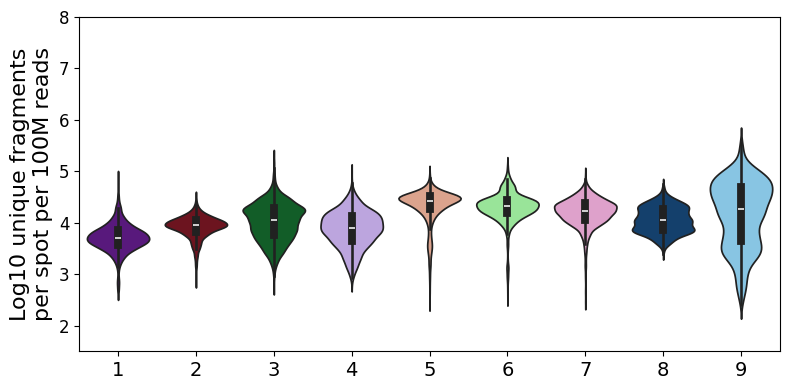

In [14]:
data = pd.DataFrame({
    'Values': list(np.log10(ffpe_mbrain)) + list(np.log10(ffpe_mcolon)) + list(np.log10(ffpe_malt)) + \
    list(np.log10(frag_mbrain)) + list(np.log10(frag_ME11)) + \
    list(np.log10(frag_htonsil)) + \
    list(np.log10(frag_sATAC_E12)) + \
    list(np.log10(ffpe_LM19)) + list(np.log10(frag_cuttag_E11)),
    'Group': ['1'] * len(ffpe_mbrain) + ['2'] * len(ffpe_mcolon) + ['3'] * len(ffpe_malt) + \
    ['4'] * len(frag_mbrain) + ['5'] * len(frag_ME11) + \
    ['6'] * len(frag_htonsil) + \
    ['7'] * len(frag_sATAC_E12) + \
    ['8'] * len(ffpe_LM19) + ['9'] * len(frag_cuttag_E11)
})

# Create the violin plot
plt.figure(figsize=(8,4))
sns.violinplot(x='Group', y='Values', data=data,
              palette=['#5c088c', '#7a0614','#066923','#ba9be8','#e89d80','#8df08d','#e897cf','#06407a','#79caf2'])
plt.xlabel('')
plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=12)
plt.ylabel('Log10 unique fragments\nper spot per 100M reads', fontsize=16)
plt.ylim(1.5,8)
plt.tight_layout()
plt.savefig('fragment_2.png', dpi=300)
plt.show()

In [23]:
frip_mbrain = list(pd.read_csv('yx_mbrain/yx_mbrain_signac_meta.csv', index_col=0)['FRiP'])
frip_ME11 = list(pd.read_csv('yx_ME11/yx_ME11_signac_meta.csv', index_col=0)['FRiP'])
frip_htonsil = list(pd.read_csv('yx_htonsil/yx_htonsil_signac_meta.csv', index_col=0)['FRiP'])
frip_sATAC_E12 = list(pd.read_csv('sATAC_E12/sATAC_E12_signac_meta.csv', index_col=0)['FRiP'])
frip_cuttag_E11 = list(pd.read_csv('yx_cuttag_E11/yx_CUTTag_ME11_signac_meta.csv', index_col=0)['FRiP'])

frip_ffpe_mbrain = list(pd.read_csv('../signac_output/mouse_brain_atac_20240828_meta.csv', index_col=0)['FRiP'])
frip_ffpe_mcolon = list(pd.read_csv('../signac_output/mouse_colon_20240910_meta.csv', index_col=0)['FRiP'])
frip_ffpe_malt = list(pd.read_csv('../MALT100/signac_output/20241014_MALT_8444x102293_meta.csv', index_col=0)['FRiP'])
frip_ffpe_LM19 = list(pd.read_csv('../signac_output/LYM_K27/20241108_LYM_K27_2400x21461_meta.csv', index_col=0)['FRiP'])

In [24]:
df1=pd.read_csv('sATAC_E12/sATAC_E12_signac_meta.csv', index_col=0)
df1=df1[df1['fragments'] > 100]
frip_sATAC_E12 = list(df1['FRiP'])

df2=pd.read_csv('yx_cuttag_E11/yx_CUTTag_ME11_signac_meta.csv', index_col=0)
df2=df2[df2['fragments'] > 100]
frip_cuttag_E11 = list(df2['FRiP'])

/tmp/ipykernel_3167152/1995786315.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Group', y='Values', data=data,


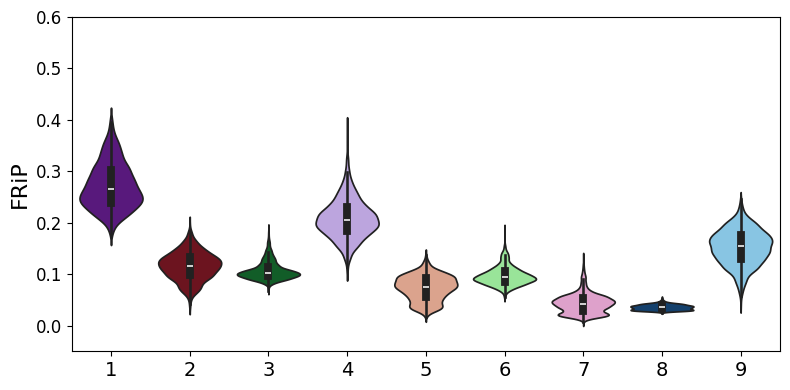

In [32]:
data = pd.DataFrame({
    'Values': frip_ffpe_mbrain + frip_ffpe_mcolon + frip_ffpe_malt + \
    frip_mbrain + frip_ME11 + \
    frip_htonsil + \
    frip_sATAC_E12 + \
    frip_ffpe_LM19 + frip_cuttag_E11,
    'Group': ['1'] * len(frip_ffpe_mbrain) + ['2'] * len(frip_ffpe_mcolon) + ['3'] * len(frip_ffpe_malt) + \
    ['4'] * len(frip_mbrain) + ['5'] * len(frip_ME11) + \
    ['6'] * len(frip_htonsil) + \
    ['7'] * len(frip_sATAC_E12) + \
    ['8'] * len(frip_ffpe_LM19) + ['9'] * len(frip_cuttag_E11)
})

# Create the violin plot
plt.figure(figsize=(8,4))
sns.violinplot(x='Group', y='Values', data=data,
              palette=['#5c088c', '#7a0614','#066923','#ba9be8','#e89d80','#8df08d','#e897cf','#06407a','#79caf2'])
plt.xlabel('')
plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=12)
plt.ylabel('FRiP', fontsize=16)
plt.ylim(-0.05,0.6)
plt.tight_layout()
plt.savefig('FRiP.png', dpi=300)
plt.show()

In [30]:
blacklist_fraction_mbrain = list(pd.read_csv('yx_mbrain/yx_mbrain_signac_meta.csv', index_col=0)['blacklist_fraction'])
blacklist_fraction_ME11 = list(pd.read_csv('yx_ME11/yx_ME11_signac_meta.csv', index_col=0)['blacklist_fraction'])
blacklist_fraction_htonsil = list(pd.read_csv('yx_htonsil/yx_htonsil_signac_meta.csv', index_col=0)['blacklist_fraction'])
blacklist_fraction_sATAC_E12 = list(pd.read_csv('sATAC_E12/sATAC_E12_signac_meta.csv', index_col=0)['blacklist_fraction'])
blacklist_fraction_cuttag_E11 = list(pd.read_csv('yx_cuttag_E11/yx_CUTTag_ME11_signac_meta.csv', index_col=0)['blacklist_fraction'])

blacklist_fraction_ffpe_mbrain = list(pd.read_csv('../signac_output/mouse_brain_atac_20240828_meta.csv', index_col=0)['blacklist_fraction'])
blacklist_fraction_ffpe_mcolon = list(pd.read_csv('../signac_output/mouse_colon_20240910_meta.csv', index_col=0)['blacklist_fraction'])
blacklist_fraction_ffpe_malt = list(pd.read_csv('../MALT100/signac_output/20241014_MALT_8444x102293_meta.csv', index_col=0)['blacklist_fraction'])
blacklist_fraction_ffpe_LM19 = list(pd.read_csv('../signac_output/LYM_K27/20241108_LYM_K27_2400x21461_meta.csv', index_col=0)['blacklist_fraction'])

In [31]:
df1=pd.read_csv('sATAC_E12/sATAC_E12_signac_meta.csv', index_col=0)
df1=df1[df1['fragments'] > 100]
blacklist_fraction_sATAC_E12 = list(df1['blacklist_fraction'])

In [32]:
df2=pd.read_csv('yx_cuttag_E11/yx_CUTTag_ME11_signac_meta.csv', index_col=0)
df2=df2[df2['fragments'] > 100]
blacklist_fraction_cuttag_E11 = list(df2['blacklist_fraction'])

/tmp/ipykernel_537277/3492275756.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Group', y='Values', data=data,


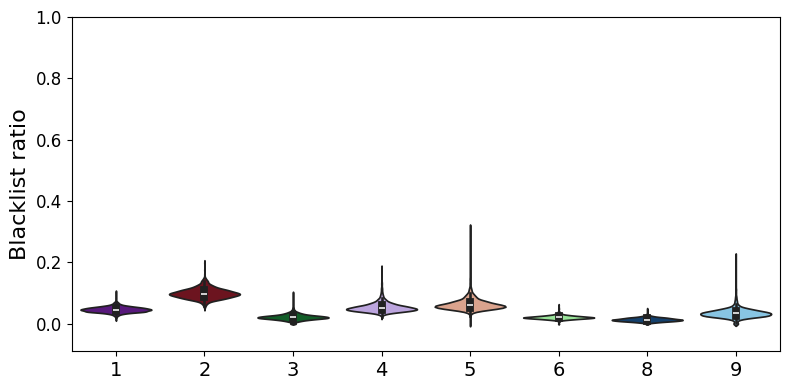

In [36]:
data = pd.DataFrame({
    'Values': blacklist_fraction_ffpe_mbrain + blacklist_fraction_ffpe_mcolon + blacklist_fraction_ffpe_malt + \
    blacklist_fraction_mbrain + blacklist_fraction_ME11 + \
    blacklist_fraction_htonsil + \
    blacklist_fraction_ffpe_LM19 + blacklist_fraction_cuttag_E11,
    'Group': ['1'] * len(blacklist_fraction_ffpe_mbrain) + ['2'] * len(blacklist_fraction_ffpe_mcolon) + ['3'] * len(blacklist_fraction_ffpe_malt) + \
    ['4'] * len(blacklist_fraction_mbrain) + ['5'] * len(blacklist_fraction_ME11) + \
    ['6'] * len(blacklist_fraction_htonsil) + \
    ['8'] * len(blacklist_fraction_ffpe_LM19) + ['9'] * len(blacklist_fraction_cuttag_E11)
})

# Create the violin plot
plt.figure(figsize=(8,4))
sns.violinplot(x='Group', y='Values', data=data,
              palette=['#5c088c', '#7a0614','#066923','#ba9be8','#e89d80','#8df08d','#06407a','#79caf2'])
plt.xlabel('')
plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=12)
plt.ylabel('Blacklist ratio', fontsize=16)
plt.ylim(-0.09,1)
plt.tight_layout()
plt.savefig('blacklist_2.png', dpi=300)
plt.show()